# Load the data

In [2]:
%run env.ipynb

In [3]:
import pickle
import numpy as np
from jLM.RDME import File as RDMEFile
import jLM

In [4]:
# traj_fname = "/data2/2024_Yeast_GS/code_sif/sim/yeast-dummy-mrna.lm"
# traj = RDMEFile(traj_fname)
# odeTraj = pickle.load(open(traj_fname + "_ode.pkl", "rb"))
traj_dir = "/data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20241107wtmt_ramsey"
# traj_file = "yeast_20240823_2_t60.0minGAE2.0mM.lm"
traj_file = "yeast1.12.4mt_multi_20241030_2_t420.0minGAE5.55mMramsey_wt_gpu4.lm"
traj_suff = "_ode.jsonl"
# This is the original data 
# traj_dir = "/data2/2024_Yeast_GS/code_sif/sim/"
# traj_file = "yeast-dummy-mrna.lm"
# traj_suff = ".pkl"
traj_fname = traj_dir+traj_file
traj = RDMEFile(traj_dir+traj_file)
odeTraj = pickle.load(open(traj_dir+traj_file+ traj_suff, "rb"))
## this is original 
## this file is generated by sciprt getStats.py
# rdmePerCompartment = pickle.load(open(traj_dir+"pstats-dummy-mrna.pkl", "rb"))




None
RESIZING!!!
Byte lattice initialized


In [6]:
print(f"Shape of odeTraj['ts']: {odeTraj['ts'].shape}")
print(f"Shape of odeTraj['ys']: {odeTraj['ys'].shape}")
print(f"Number of species: {len(odeTraj['names'])}")

Shape of odeTraj['ts']: (36001,)
Shape of odeTraj['ys']: (36001, 6)
Number of species: 6


## Show some statistics parameters of the simulation 


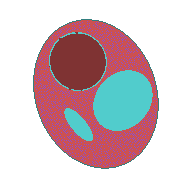

In [6]:
traj

In [5]:
traj.showReactions()

Index,Reaction,Rate,Regions
0,$\mathrm{G4}\overset{k_{\mathrm{fd}}}{\longrightarrow}\mathrm{G4d}$,3.583 × 1010 M-1⋅s-1,"cytoplasm, nucleoplasm"
1,$\mathrm{G4d}\overset{k_{\mathrm{rd}}}{\longrightarrow}\mathrm{G4} + \mathrm{G4}$,1.667 × 10-5 s-1,"cytoplasm, nucleoplasm"
2,$\mathrm{G80}\overset{k_{\mathrm{fd}}}{\longrightarrow}\mathrm{G80d}$,3.583 × 1010 M-1⋅s-1,"cytoplasm, nucleoplasm"
3,$\mathrm{G80d}\overset{k_{\mathrm{rd}}}{\longrightarrow}\mathrm{G80} + \mathrm{G80}$,1.667 × 10-5 s-1,"cytoplasm, nucleoplasm"
4,$\mathrm{DG1} + \mathrm{G4d}\overset{k_{\mathrm{f1\_4}}}{\longrightarrow}\mathrm{DG1\_G4d}$,3.583 × 107 M-1⋅s-1,nucleoplasm
5,$\mathrm{DG1\_G4d}\overset{k_{\mathrm{r1\_4}}}{\longrightarrow}\mathrm{DG1} + \mathrm{G4d}$,6.410 × 10-5 s-1,nucleoplasm
6,$\mathrm{DG1\_G4d} + \mathrm{G80d}\overset{k_{\mathrm{f2\_4}}}{\longrightarrow}\mathrm{DG1\_G4d\_G80d}$,3.583 × 105 M-1⋅s-1,nucleoplasm
7,$\mathrm{DG1\_G4d\_G80d}\overset{k_{\mathrm{r2\_4}}}{\longrightarrow}\mathrm{DG1\_G4d} + \mathrm{G80d}$,1.422 × 10-3 s-1,nucleoplasm
8,$\mathrm{DG2} + \mathrm{G4d}\overset{k_{\mathrm{f1\_5}}}{\longrightarrow}\mathrm{DG2\_G4d}$,3.583 × 107 M-1⋅s-1,nucleoplasm
9,$\mathrm{DG2\_G4d}\overset{k_{\mathrm{r1\_5}}}{\longrightarrow}\mathrm{DG2} + \mathrm{G4d}$,1.684 × 10-3 s-1,nucleoplasm


## read all species data

In [9]:
sparse_factor = 1
# Downscale the time and trajectory by a factor of 10
odeTs = odeTraj['ts'][::sparse_factor] / 60  # Convert to minutes and downscale
NAV = 6.022e23 * (traj.reg.cytoplasm.volume + traj.reg.nucleoplasm.volume + traj.reg.plasmaMembrane.volume)
odeYs = {n: odeTraj['ys'][::sparse_factor, i] * NAV for i, n in enumerate(odeTraj['names'])}  # Downscale

rdmeYs = dict()

for sp in traj.speciesList:
    ts, ys = sp.getNumberTrajectory()
    rdmeYs[sp.name] = ys[::sparse_factor]  # Downscale RDME trajectories by a factor of 10
    rdmeTs = ts[::sparse_factor] / 60  # Convert to minutes and downscale


particle numbers in sub region

In [7]:
import jLM
print(f"The location of package jLM is: {jLM.__file__}")


The location of package jLM is: /home/tianyu/miniconda3/envs/lm2.5_dev/lib/python3.7/site-packages/jLM-2.4.0-py3.7-linux-x86_64.egg/jLM/__init__.py


In [ ]:
# try to find out the number of G2 in each different region
# this function has problem not being solved yet
# g2_trajs = []
# for reg in traj.regionList:
#     ts, ys = traj.getNumberTrajectoryFromRegion(species="G2", region=reg.name, frameStart=1, frameEnd=3601)
#     g2_trajs.append(ys)
#     print(f"G2 in {reg}: {ys[-1]}")
   
    

Traj check test for 1.12

In [ ]:
# # Find the index where odeTs is close to 1
# index_close_to_1 = np.argmin(np.abs(odeTs - 0.5))
# print(f"Index when odeTs is close to 1: {index_close_to_1}")


In [ ]:
# len(odeYs['GAI'])
# odeYs['GAI'][:index_close_to_1]


In [ ]:
# odeYs['G2'][:index_close_to_1]

In [ ]:
# odeYs['G2GAI'][:index_close_to_1]

## Gene Expression States

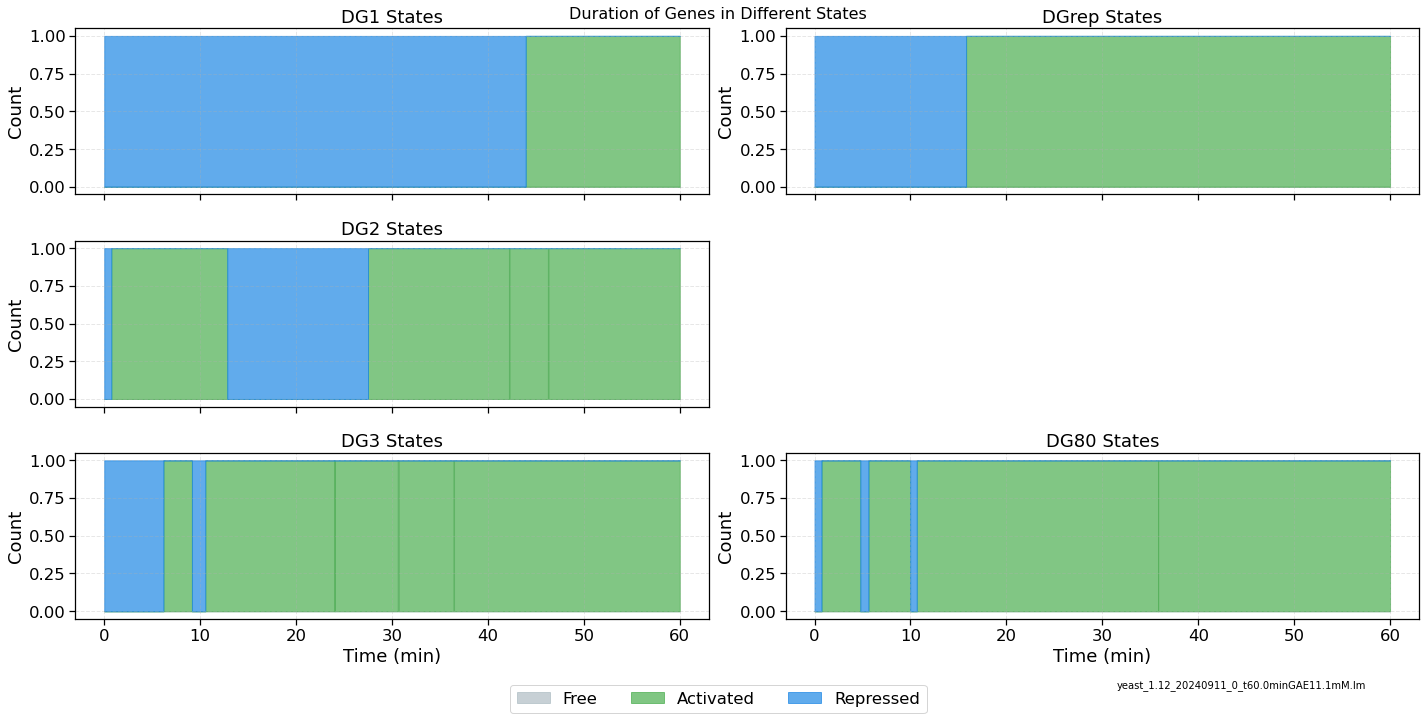

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Define the genes and their states
genes = [['DG1', 'DGrep'], ['DG2'], ['DG3', 'DG80']]
states = ['', '_G4d', '_G4d_G80d']

# Create a figure with subplots for each gene group
fig, axs = plt.subplots(3, 2, figsize=(20, 10), sharex=True)
fig.suptitle('Duration of Genes in Different States', fontsize=16, y=0.95)

# Colors for different states
colors = ['#B0BEC5', '#4CAF50', '#1E88E5']

# Create a list to store legend handles
legend_handles = []

for row, gene_row in enumerate(genes):
    for col, gene in enumerate(gene_row):
        ax = axs[row, col]
        bottom = np.zeros_like(rdmeTs)
        
        for j, state in enumerate(states):
            species_name = f'{gene}{state}'
            if species_name in rdmeYs:
                values = rdmeYs[species_name]
                handle = ax.fill_between(rdmeTs, bottom, bottom + values, alpha=0.7, color=colors[j])
                bottom += values
                
                # Only add to legend_handles for the first gene (to avoid duplicates)
                if row == 0 and col == 0 and j == 0:
                    legend_handles = [handle]
                elif row == 0 and col == 0:
                    legend_handles.append(handle)
        
        ax.set_ylabel('Count')
        ax.set_title(f'{gene} States')
        ax.grid(True, linestyle='--', alpha=0.3)

    # Hide unused subplot
    if len(gene_row) == 1:
        axs[row, 1].set_visible(False)

# Set x-label for bottom subplots
for ax in axs[-1, :]:
    ax.set_xlabel('Time (min)')

# Add a single legend for all subplots
fig.legend(legend_handles, ['Free', 'Activated', 'Repressed'], 
           loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3)

# Add the file_name as a string in the bottom right of the figure
plt.gcf().text(0.95, 0.00, traj_file, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

plt.tight_layout()
plt.subplots_adjust(bottom=0.1, top=0.92)  # Adjust these values to make room for the title and legend

# Save the figure
fig.savefig(traj_dir + traj_file + '_gene_states_duration.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

create a table

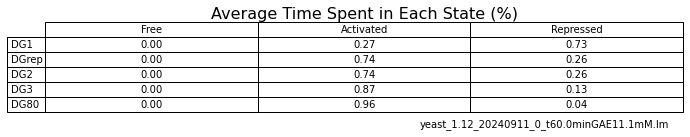

In [7]:
import numpy as np
import matplotlib.pyplot as plt

genes = ['DG1', 'DGrep', 'DG2', 'DG3', 'DG80']
states = ['', '_G4d', '_G4d_G80d']
total_time = rdmeTs[-1] - rdmeTs[0]

avg_times = {}
for gene in genes:
    avg_times[gene] = {}
    for state in states:
        species_name = f'{gene}{state}'
        if species_name in rdmeYs:
            avg_time = np.trapz(rdmeYs[species_name], rdmeTs) / total_time
            avg_times[gene][state] = avg_time
        else:
            avg_times[gene][state] = 0

fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')

cell_text = [[f"{avg_times[gene][state]:.2f}" for state in states] for gene in genes]
table = ax.table(cellText=cell_text, rowLabels=genes, colLabels=['Free', 'Activated', 'Repressed'], cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title("Average Time Spent in Each State (%)", fontsize=16, pad=0)
plt.gcf().text(0.95, 0.01, traj_file, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

plt.tight_layout()
fig.savefig(traj_dir + traj_file + '_gene_states_duration_table.png', dpi=300, bbox_inches='tight')
plt.show()

## All species plot

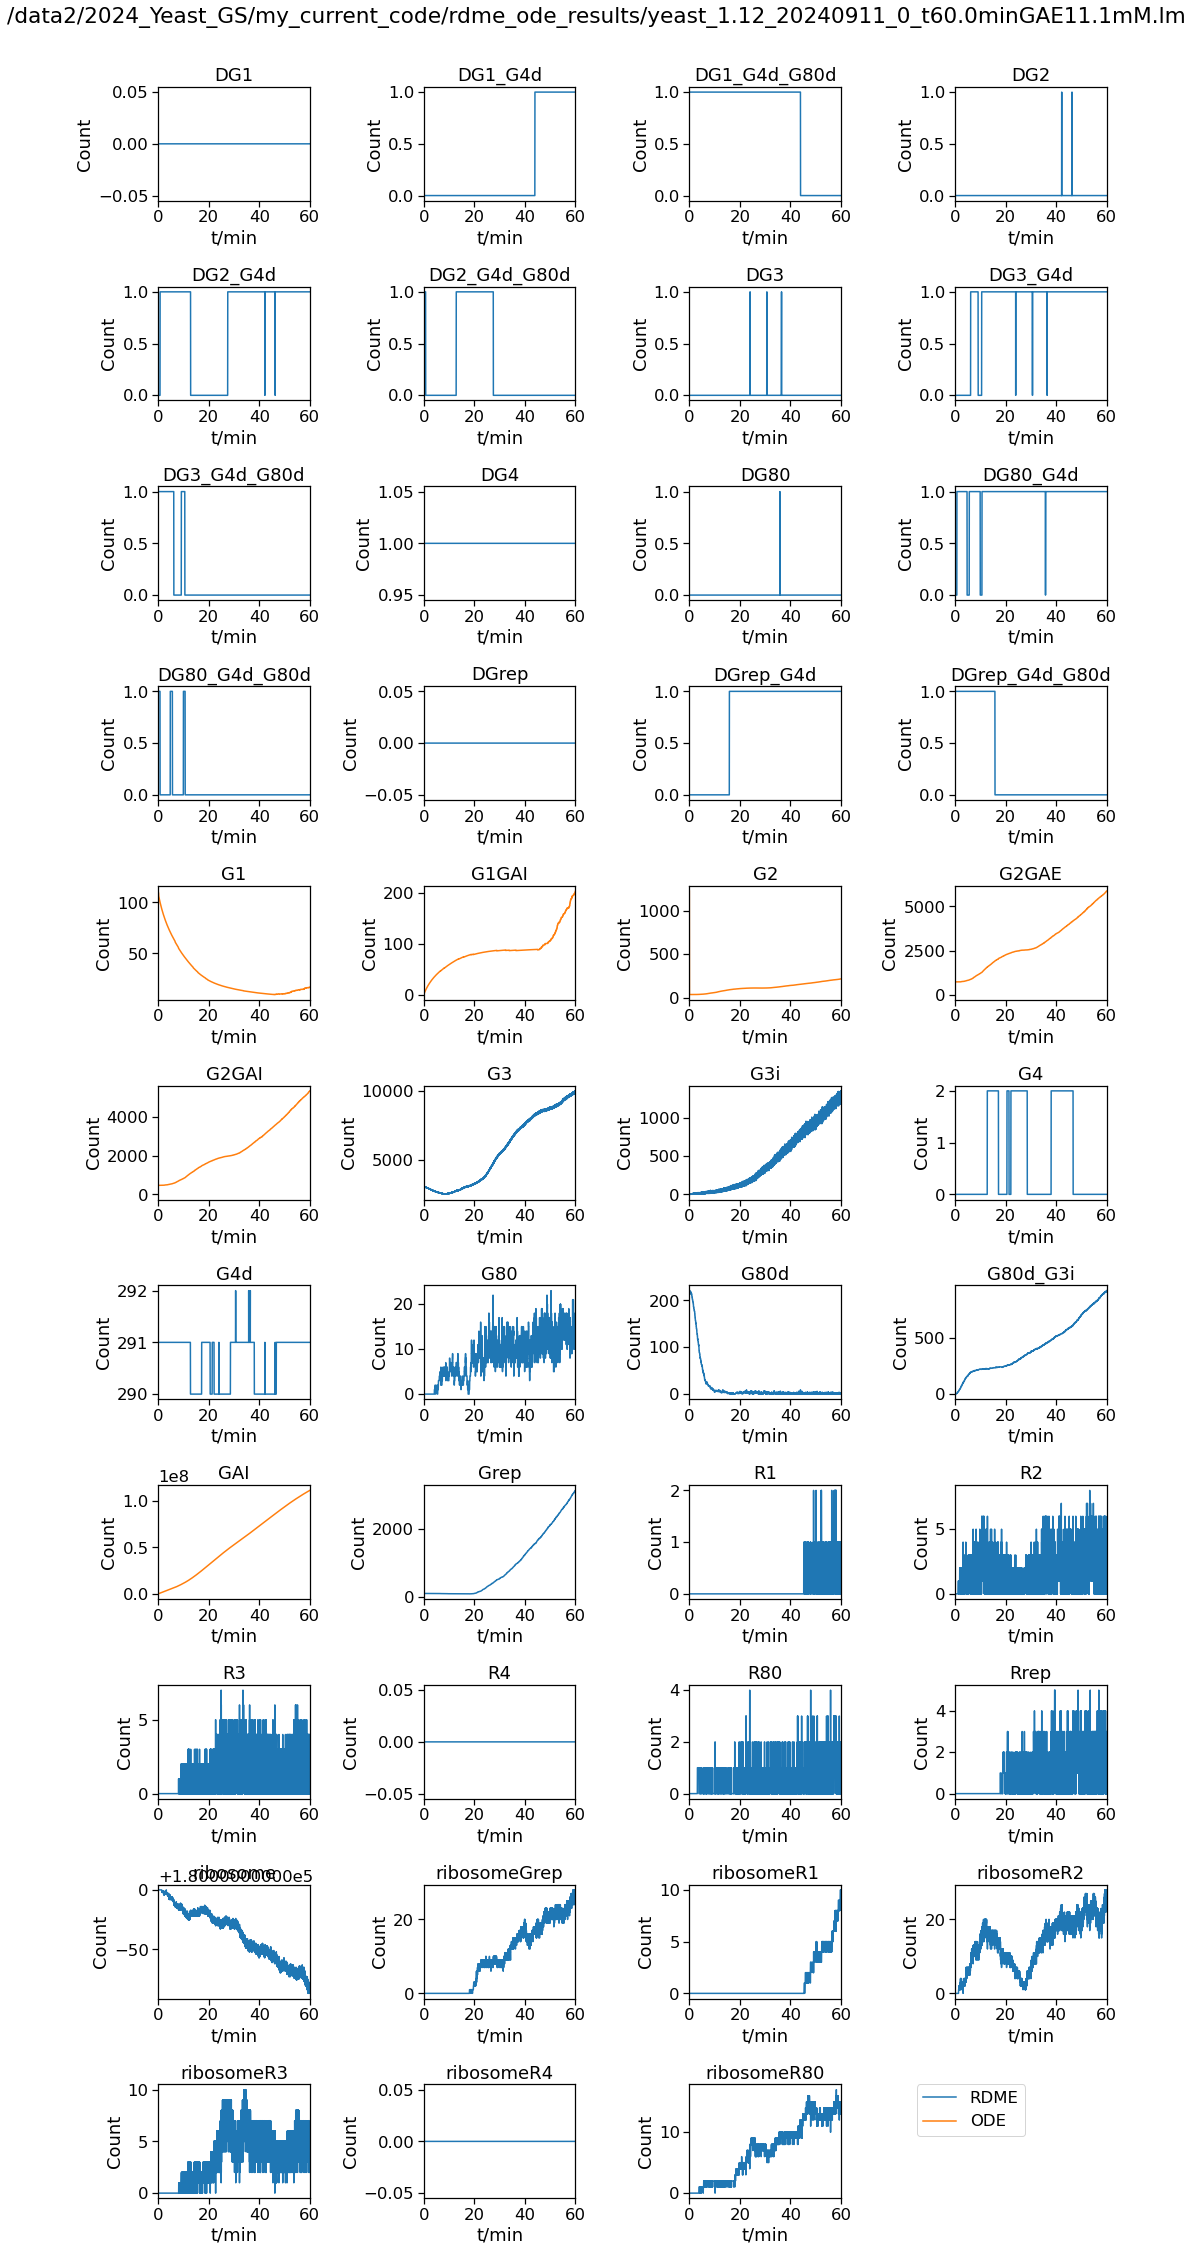

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming rdmeYs, odeYs, rdmeTs, odeTs, and traj_fname are already defined

# Prepare names and plot layout
names = sorted(filter(lambda x: x[0], set(rdmeYs.keys()) | set(odeYs.keys())))
nplots = len(names)
ncols = 4
nrows = int(np.ceil(nplots / ncols))

# Arguments for the axes
# axargs = dict(xlim=(min(odeTs.min(), rdmeTs.min()), max(odeTs.max(), rdmeTs.max())),
#               xlabel='t/min', ylabel='Count', xticks=np.arange(0, 61, 10))
axargs = dict(xlim=(min(odeTs.min(), rdmeTs.min()), max(odeTs.max(), rdmeTs.max())),
              xlabel='t/min', ylabel='Count')
# Create figure and subplots
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(15, 3 * nrows))

# Adjust layout to make space for the suptitle
fig.subplots_adjust(top=0.90)

# Add a title to the figure without overlapping with subplots
fig.suptitle(str(traj_fname), y=0.95)

axs = axs.ravel()
colors = sns.color_palette()

# Plot data
for ax, name in zip(axs, names):
    if name in rdmeYs:
        if name not in ['G1', 'G2']:
            rdmeHandle = ax.plot(rdmeTs, rdmeYs[name], c=colors[0], label="RDME")[0]
    if name in odeYs:
        odeHandle = ax.plot(odeTs, odeYs[name], c=colors[1], label="ODE")[0]
    ax.set(title=name, **axargs)

# Remove empty subplots
for i, ax in enumerate(axs):
    if i >= nplots:
        ax.remove()

# Tight layout to adjust subplots spacing
fig.tight_layout(rect=[0, 0, 1, 0.95])

# Add legend to the last subplot
axs[nplots - 1].legend([rdmeHandle, odeHandle], ["RDME", "ODE"], bbox_to_anchor=(1.5, 1), loc=2, borderaxespad=0.)

# Save the figure
fig.savefig(traj_fname + 'all_species_counts' + '.png', dpi=300)


print initial counts for species 

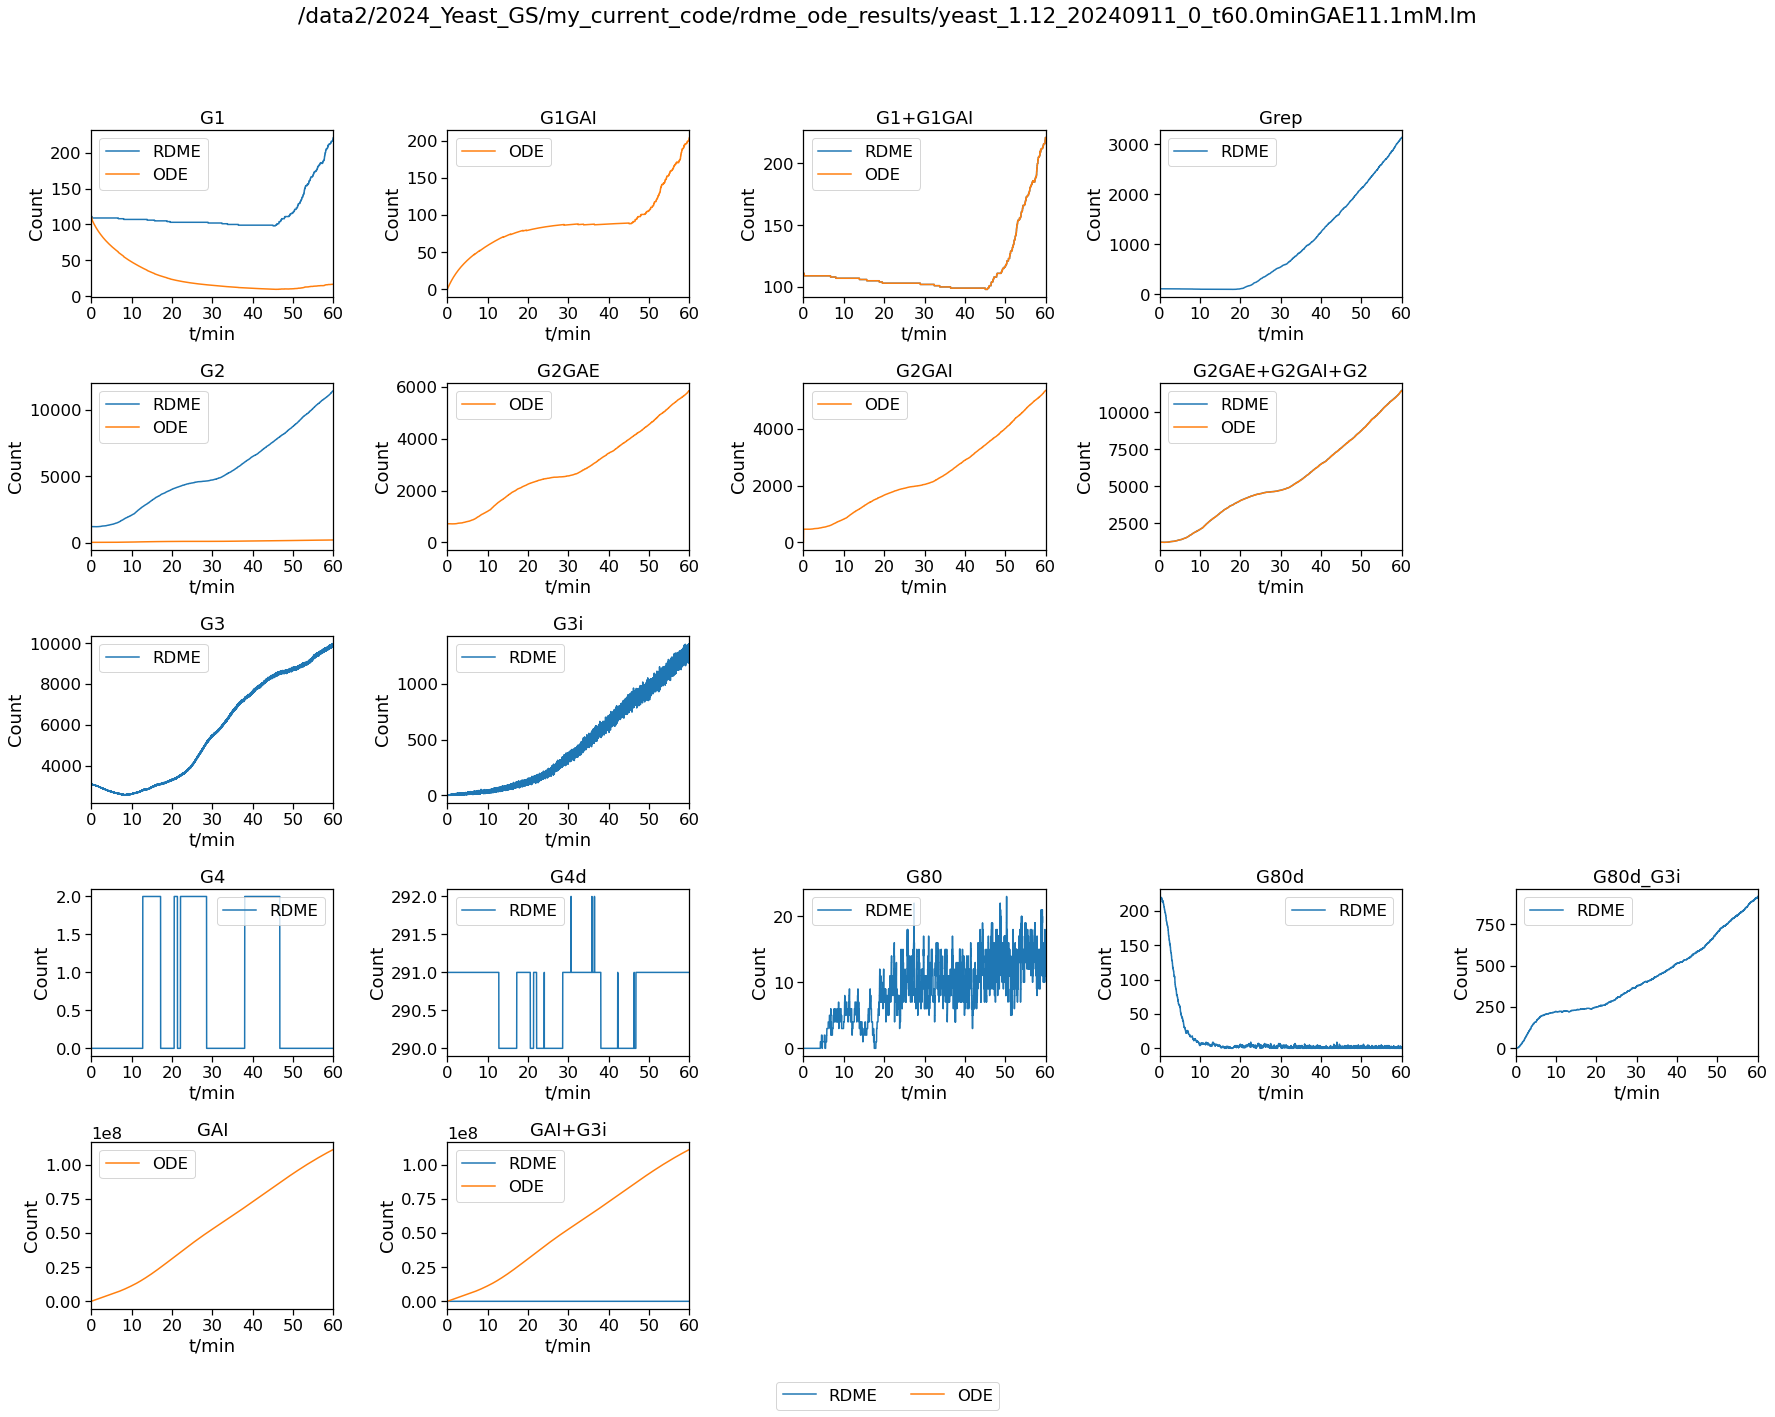

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the species to plot in the specified order
species_order = [
    ['G1', 'G1GAI', 'G1+G1GAI', 'Grep'],
    ['G2', 'G2GAE', 'G2GAI', 'G2GAE+G2GAI+G2'],
    ['G3', 'G3i'],
    ['G4', 'G4d', 'G80', 'G80d', 'G80d_G3i'],
    ['GAI', 'GAI+G3i']
]

# Calculate the number of rows and columns
nrows = len(species_order)
ncols = max(len(row) for row in species_order)

# Create figure and subplots
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))

# Adjust layout to make space for the suptitle
fig.subplots_adjust(top=0.95)

# Add a title to the figure without overlapping with subplots
fig.suptitle(str(traj_fname), y=0.98)

# Arguments for the axes
axargs = dict(xlim=(min(odeTs.min(), rdmeTs.min()), max(odeTs.max(), rdmeTs.max())),
              xlabel='t/min', ylabel='Count', xticks=np.arange(0, 61, 10))

colors = sns.color_palette()

# Plot data
for row, species_row in enumerate(species_order):
    for col, species in enumerate(species_row):
        ax = axs[row, col]
        
        if '+' in species:
            # Sum the counts for combined species
            species_list = species.split('+')
            rdme_sum = np.sum([rdmeYs.get(sp, np.zeros_like(rdmeTs)) for sp in species_list], axis=0)
            ode_sum = np.sum([odeYs.get(sp, np.zeros_like(odeTs)) for sp in species_list], axis=0)
            
            rdmeHandle = ax.plot(rdmeTs, rdme_sum, c=colors[0], label="RDME")[0]
            odeHandle = ax.plot(odeTs, ode_sum, c=colors[1], label="ODE")[0]
        else:
            if species in rdmeYs:
                rdmeHandle = ax.plot(rdmeTs, rdmeYs[species], c=colors[0], label="RDME")[0]
            if species in odeYs:
                odeHandle = ax.plot(odeTs, odeYs[species], c=colors[1], label="ODE")[0]
        
        ax.set(title=species, **axargs)
        ax.legend()

    # Remove empty subplots in the row
    for col in range(len(species_row), ncols):
        fig.delaxes(axs[row, col])

# Tight layout to adjust subplots spacing
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

# Add legend to the figure
fig.legend([rdmeHandle, odeHandle], ["RDME", "ODE"], 
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0))

# Save the figure
fig.savefig(traj_fname + 'selected_species_counts.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
break

## Species Specific Plot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Filter names to include only those with 'G2' or 'R2'
interested_species ='G2'
gene_name = 'DG' + interested_species[1:]
mrna_name = 'R' + interested_species[1:]
names = sorted(filter(lambda x: interested_species in x or mrna_name in x, set(rdmeYs.keys()) | set(odeYs.keys())))
nplots = len(names) - 2


ncols = 3
nrows = int(np.ceil((nplots - 1)  / ncols))  # -1 because we're replacing 3 DG2 plots with 1

# Arguments for the axes
axargs = dict(xlim=(min(odeTs.min(), rdmeTs.min()), max(odeTs.max(), rdmeTs.max())),
              xlabel='t/min', ylabel='Count', xticks=np.arange(0, 61, 10))

# Create figure and subplots
fig = plt.figure(figsize=(15, 6 * nrows))
gs = GridSpec(nrows + 1, ncols, figure=fig)  # +1 for the DG2 stacked area chart
fig.subplots_adjust(top=0.95)

# Add a title to the figure without overlapping with subplots
fig.suptitle(f"{interested_species} related species - {traj_file}", y=0.98)

# Create the stacked area chart for DG2
ax = fig.add_subplot(gs[0, :])
gene_sates = ['', '_G4d', '_G4d_G80d']
ode_DG = rdmeYs[gene_name]
ode_DG_G4d = rdmeYs[gene_name + gene_sates[1]]
ode_DG_G4d_G80d = rdmeYs[gene_name + gene_sates[2]]

gene_colors = ['#B0BEC5', '#4CAF50', '#1E88E5']
ax.fill_between(rdmeTs, 0, ode_DG, color=gene_colors[0], alpha=0.5, label='free')
ax.fill_between(rdmeTs, ode_DG, ode_DG + ode_DG_G4d, color=gene_colors[1], alpha=0.5, label='activated')
ax.fill_between(rdmeTs, ode_DG + ode_DG_G4d, ode_DG + ode_DG_G4d + ode_DG_G4d_G80d, color=gene_colors[2], alpha=0.5, label='repressed')
ax.set(title='DG2 States', **axargs)
ax.legend()

# Plot the rest of the species
for i, name in enumerate(names):
    if gene_name not in name:
        print(name)
        ax = fig.add_subplot(gs[(i) // ncols , (i) % ncols])
        if name in rdmeYs:
            rdmeHandle = ax.plot(rdmeTs, rdmeYs[name], c=colors[0], label="RDME")[0]
        if name in odeYs:
            odeHandle = ax.plot(odeTs, odeYs[name], c=colors[1], label="ODE")[0]
        ax.set(title=name, **axargs)

# Tight layout to adjust subplots spacing
fig.tight_layout(rect=[0, 0.04, 1, 1])
colors = sns.color_palette()

# Add legend to the figure
fig.legend([rdmeHandle, odeHandle], ["RDME", "ODE"], 
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.02))

# Save the figure
fig.savefig(traj_dir + traj_file + f'_{interested_species}_species_counts.png', dpi=300, bbox_inches='tight')

## GAI

In [ ]:
# plot a figure only show the species GAI from od
fig, ax = plt.subplots()
ax.plot(odeTs, (odeYs['GAI']+odeYs['G1GAI'])/NAV*1e3, c=colors[1], label="Internal")
ax.plot(odeTs, np.full(odeTs.size, 2), c=colors[2], label="External")
#xlabel and y label
ax.set(xlabel='t/min', ylabel='mM')
ax.legend()
ax.set(title=f"Galactose concentration - {traj_file}")
# Save the figure
fig.savefig(traj_fname + 'GAI&GAE' + '.png', dpi=300)
# plot the final number in (odeYs['GAI']+odeYs['G1GAI'])/NAV*1e3
print((odeYs['GAI'][-1]+odeYs['G1GAI'][-1])/NAV*1e3)

## G2 comparison

In [ ]:
# print out the initial, final and min of the rdme_G2
rdme_G2 = rdmeYs['G2']
print("rdme_G2 initial: ", rdme_G2[0])
print("rdme_G2 final: ", rdme_G2[-1])
print("rdme_G2 min: ", min(rdme_G2))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
ode_G2 = odeYs['G2']
ode_G2GAI = odeYs['G2GAI']
ode_G2GAE = odeYs['G2GAE']
rdme_G2 = rdmeYs['G2']

# Downsample factor
downsample_factor = 10  # Adjust this factor as needed

# Downsample the data
odeTs_downsampled = odeTs[::downsample_factor]
ode_G2_downsampled = ode_G2[::downsample_factor]
ode_G2GAI_downsampled = ode_G2GAI[::downsample_factor]
ode_G2GAE_downsampled = ode_G2GAE[::downsample_factor]
rdmeTs_downsampled = rdmeTs[::downsample_factor]
rdme_G2_downsampled = rdme_G2[::downsample_factor]

# Create a figure and axis
fig, ax = plt.subplots()

# Plot the filled area for G2 in ODE 
ax.fill_between(odeTs_downsampled, ode_G2_downsampled + ode_G2GAI_downsampled, ode_G2_downsampled + ode_G2GAI_downsampled + ode_G2GAE_downsampled, color='orange', alpha=0.5, label='G2GAE in ODE')
ax.fill_between(odeTs_downsampled, ode_G2_downsampled, ode_G2_downsampled + ode_G2GAI_downsampled, color='red', alpha=0.5, label='G2GAI in ODE')
ax.fill_between(odeTs_downsampled, 0, ode_G2_downsampled, color='blue', alpha=0.5, label='G2 in ODE')
# Calculate final counts
final_count = rdme_G2[-1]
# Add final count to the plot
# Add final count to the plot with smaller font size
plt.gcf().text(1, 0.35, f'Final Count: {int(final_count)}' ,
               verticalalignment='bottom', horizontalalignment='left', 
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# Plot the combined trajectory as a line
ax.plot(rdmeTs_downsampled, rdme_G2_downsampled, color='black', label='G2 total from RDME')

# Customize the plot
ax.set_xlabel('Time(min)')
ax.set_ylabel('Counts')
ax.set_title(f'Transporter(G2) counts in {traj_file}')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Show the plot
plt.show()

## G1 comparison

In [ ]:
rdme_G1 = rdmeYs['G1']
print("rdme_G1 initial: ", rdme_G1[0])
print("rdme_G final: ", rdme_G1[-1])
print("rdme_G1 min: ", min(rdme_G1))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
ode_G1 = odeYs['G1']
ode_G1GAI = odeYs['G1GAI']
rdme_G1 = rdmeYs['G1']

# Create a figure and axis
fig, ax = plt.subplots()

# Plot the filled area for G2 in ODE 
ax.fill_between(odeTs, 0, ode_G1, color='blue', alpha=0.5, label='G1 in ODE')


ax.fill_between(odeTs, ode_G1, ode_G1+ode_G1GAI, color='red', alpha=0.5, label='G1GAI in ODE')

# Plot the combined trajectory as a line
ax.plot(rdmeTs, rdme_G1, color='black', label='G1 total from RDME')

# Customize the plot
ax.set_xlabel('Time(min)')
ax.set_ylabel('Counts')
ax.set_title('G1(metabolites to degrade galactose) counts in ODE and RDME')
# ax.legend()
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

# save the fig
# plt.savefig(traj_fname+ 'G1_counts' + '.png',dpi=300)
# plt.savefig('ori_'+ 'G1_counts' + '.png',dpi=300)
# Show the plot
plt.show()



## Show G80d related stuff

In [ ]:
# def boxcar(ts,ys,factor):
#     ts2 = np.zeros(ts.size//factor)
#     ys2 = np.zeros(ts.size//factor)
#     n = factor*(ts.size//factor)
#     for i in range(factor):
#         ts2 += ts[i:n:factor]
#         ys2 += ys[i:n:factor]
#     return ts2/factor, ys2/factor

In [ ]:
# g80dimers = ['DG2_G4d_G80d', 'G80d', 'RGrep', 'DGrep_G4d_G80d', 'DG80_G4d_G80d', 'DG3_G4d_G80d', 'G80G3i',  'DG1_G4d_G80d']
# g80monomers = ['G80']

In [ ]:
# nucNs = (sum(rdmePerCompartment[x]['nucleoplasm']['number'] for x in g80dimers)
#           + 0.5*sum(rdmePerCompartment[x]['nucleoplasm']['number'] for x in g80monomers))
# allNs = (sum(rdmeYs[x] for x in g80dimers) + 0.5*sum(rdmeYs[x] for x in g80monomers))

# nucCs = (sum(rdmePerCompartment[x]['nucleoplasm']['conc'] for x in g80dimers)
#           + 0.5*sum(rdmePerCompartment[x]['nucleoplasm']['conc'] for x in g80monomers))
# cytCs = (sum(rdmePerCompartment[x]['cytoplasm']['conc'] for x in g80dimers)
#           + 0.5*sum(rdmePerCompartment[x]['cytoplasm']['conc'] for x in g80monomers))

# deci = 200
# deciTs, nuclearFraction = boxcar(rdmeTs, nucNs/allNs, deci)
# deciTs, nuclearConc = boxcar(rdmeTs, nucCs, deci)
# deciTs, cytoConc = boxcar(rdmeTs, cytCs, deci)

# nuclearConc = nuclearConc/1e-9
# cytoConc = cytoConc/1e-9

In [ ]:
# fig, ax = plt.subplots(figsize=(5,3.5))

# ax.plot(deciTs[:60], nuclearConc[:60], label="Nucleus")
# ax.plot(deciTs[:60], cytoConc[:60], label="Cytoplasm")
# # ax.set(xlim=(deciTs[0], deciTs[-1]), xlabel="t(min)", ylabel="nM")
# ax.set(xlim=(deciTs[0], 60), xlabel="t(min)", ylabel="nM")
# ax.legend()
# ax.title.set_text("Concentration of G$_{80}$ dimer")
# # add annotation to the plot

# # fig.tight_layout()
# plt.savefig('G80_concentration.png',dpi=300,bbox_inches='tight')

In [ ]:
# # fig, ax = plt.subplots(figsize=(5,3.5))
# fig, ax = plt.subplots()
# ax.plot(deciTs, nuclearFraction, label="$n_{\mathrm{G80}}$ nuc./total")
# ax.plot(odeTs, 1e3*odeYs["GAI"]/NAV/11.1, label="[Gal] cyt./ext.")
# # ax.set(xlim=(deciTs[0], deciTs[-1]), ylim=(0,0.4), xlabel="t/min", ylabel="Fraction")
# ax.set(xlim=(deciTs[0], 60), ylim=(0,0.4), xlabel="t/min", ylabel="Fraction")
# ax.legend()
# ax.title.set_text("Fraction of G$_{80}$ in nucleus, [Gal] in cytoplasm/extra-cellular")
# # fig.tight_layout()
# fig.savefig('fraction.png',dpi=300,bbox_inches='tight')

In [ ]:
# fig, ax = plt.subplots(figsize=(0.8*6,0.8*3.5))
# ax2 = ax.twinx()
# #ax.plot(deciTs, nuclearFraction, label="$n_{\mathrm{G80}}$ nuc./total")

# nmemg2 = rdmePerCompartment['G2']['plasmaMembrane']['number']
# _, nmemg2 = boxcar(rdmeTs, nmemg2, deci)
# colors = sns.color_palette()

# g2plot = ax.plot(deciTs, nmemg2/1e3, c=colors[0])[0]
# gaiplot = ax2.plot(odeTs, 1e3*odeYs["GAI"]/NAV, c=colors[1])[0]
# ax.set(xlim=(deciTs[0], deciTs[-1]), xlabel="t/min")
# ax2.set(xlim=(deciTs[0], deciTs[-1]), xlabel="t/min")
# ax2.set(ylabel=r"[Gal]$_{\mathrm{int}}$/mM", ylim=(0,6))
# ax.set(ylabel=r"n$_{\mathrm{G2}}$/$10^{3}$", ylim=(0,13))
# ax.legend([g2plot,gaiplot], ["G2", "Internal galactose"])
# fig.tight_layout()